In [6]:
from absl import logging

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import seaborn as sns

# Using a Universal Sentence Encoder model which is designed to take raw text input
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model=hub.load(module_url)
print("module %s loaded" % module_url)
def embed(input):
  # For USE models, you can typically call the loaded model directly with the input
  return model(input)

module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


In [7]:
word="Elephant"
sentence="I am a sentence for which I would like to get its work"
paragraph=(
    "Universal Sentence Encoder embeddings also support short paragraphs. "
    "There is no hard limit on how long the paragraph is. Roughly, the longer "
    "the more 'diluted' the embedding will be."
)

messages=[word,sentence, paragraph]

logging.set_verbosity(logging.ERROR)

# Call the embed function directly, which uses the loaded USE model
message_embeddings = embed(messages)

# Convert the TensorFlow tensor to a NumPy array
message_embeddings = message_embeddings.numpy()

for i, message_embedding in enumerate(message_embeddings):

    print("Message: {}".format(messages[i]))

    print("Embedding size: {}".format(len(message_embedding)))

    message_embedding_snippet = message_embedding[:3]

    print("Embedding: [{}, ...]\n".format(
        ", ".join(map(str, message_embedding_snippet))
    ))

Message: Elephant
Embedding size: 512
Embedding: [0.008344488, 0.00048085835, 0.06595249, ...]

Message: I am a sentence for which I would like to get its work
Embedding size: 512
Embedding: [0.038229328, -0.045618962, 0.018797621, ...]

Message: Universal Sentence Encoder embeddings also support short paragraphs. There is no hard limit on how long the paragraph is. Roughly, the longer the more 'diluted' the embedding will be.
Embedding size: 512
Embedding: [-0.028332694, -0.05586218, -0.0129414825, ...]



In [20]:
def plot_similarity(labels, features, rotation):
  corr = np.inner(features, features)
  sns.set(font_scale=1.2)
  g = sns.heatmap(
      corr,
      xticklabels=labels,
      yticklabels=labels,
      vmin=0,
      vmax=1,
      cmap="YlOrRd")
  g.set_xticklabels(labels, rotation=rotation)
  g.set_title("Semantic Textual Similarity")

def run_and_plot(messages_):
  message_embeddings_ = embed(messages_)
  plot_similarity(messages_, message_embeddings_, 90)

  word="Elephant"
sentence="I am a sentence for which I would like to get its work"
paragraph=(
    "Universal Sentence Encoder embeddings also support short paragraphs. "
    "There is no hard limit on how long the paragraph is. Roughly, the longer "
    "the more 'diluted' the embedding will be."
)



In [8]:
!pip install seaborn tensorflow

In [17]:
def plot_similarity(labels, features, rotation):
  corr = np.inner(features, features)
  sns.set(font_scale=1.2)
  g = sns.heatmap(
      corr,
      xticklabels=labels,
      yticklabels=labels,
      vmin=0,
      vmax=1,
      cmap="YlOrRd")
  g.set_xticklabels(labels, rotation=rotation)
  g.set_title("Semantic Textual Similarity")

def run_and_plot(messages_):
  message_embeddings_ = embed(messages_)
  plot_similarity(messages_, message_embeddings_, 90)

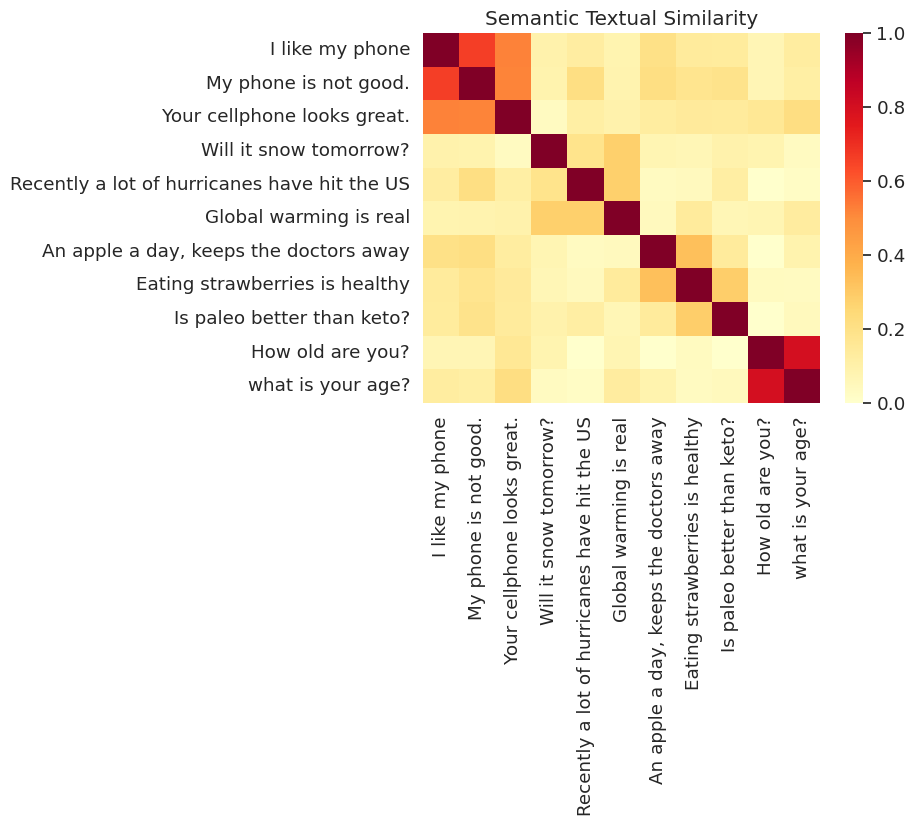

In [18]:
messages = [
    # Smartphones
    "I like my phone",
    "My phone is not good.",
    "Your cellphone looks great.",

    # Weather
    "Will it snow tomorrow?",
    "Recently a lot of hurricanes have hit the US",
    "Global warming is real",

    # Food and health
    "An apple a day, keeps the doctors away",
    "Eating strawberries is healthy",
    "Is paleo better than keto?",

    # Asking about age
    "How old are you?",
    "what is your age?",
]

run_and_plot(messages)

In [21]:
import spacy
en=spacy.blank("en")

In [22]:
text=("Donald john trump (born june 14,1946)is the 45th and current president of"
"the united states. Before entering politics, he was a businessman and telivision personality")
print(text)

Donald john trump (born june 14,1946)is the 45th and current president ofthe united states. Before entering politics, he was a businessman and telivision personality


In [23]:
doc_en=en(text)

In [26]:
from IPython.display import HTML,display
import tabulate

tokens=[[token] for token in doc_en]
display(HTML(tabulate.tabulate(tokens,tablefmt='html')))


Donald
john
trump
(
born
june
"14,1946)is"
the
45th
and
current


In [30]:
features=[[t.orth_,t.lemma_,t.pos_,t.tag_] for t in doc_en]
display(HTML(tabulate.tabulate(features,tablefmt='html')))

Donald,,,
john,,,
trump,,,
(,,,
born,,,
june,,,
"14,1946)is",,,
the,,,
45th,,,
and,,,
current,,,


In [ ]:
import spacynlp=spacy.load("en_core")